# California Housing Linear Regression

Train a regression model to predict California housing values and test the model on one datapoint.

In [1]:
# 1. Import statements
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
# 2. Getting the dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# 3. Splitting and scaling the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
# 4. Applying the algorithm
regressor = LinearRegression()
regressor.fit(X_train_scaled, y_train)

print('Model training complete.')


Model training complete.


In [5]:
# 5. Evaluating the model
y_pred = regressor.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R-squared score: {r2:.3f}')
print(f'RMSE: {rmse:.3f}')


R-squared score: 0.576
RMSE: 0.746


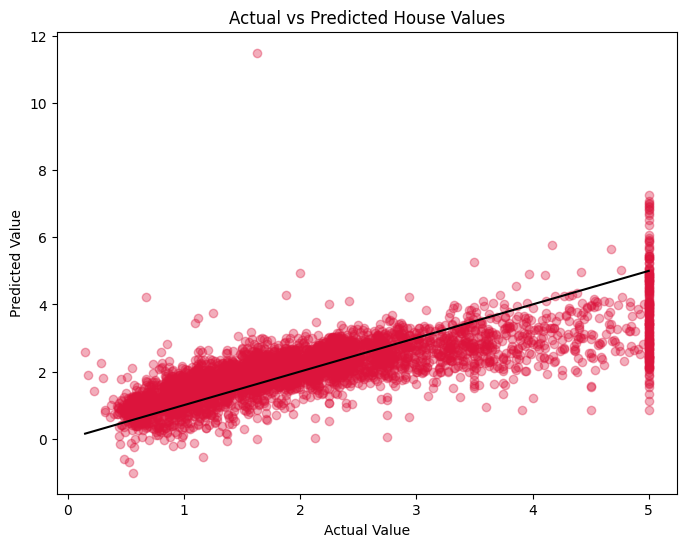

In [6]:
# 6. Graphing actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.35, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black')
plt.title('Actual vs Predicted House Values')
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.show()


In [7]:
# 7. Testing against one datapoint
sample_index = 0
sample = X_test.iloc[[sample_index]]
sample_scaled = scaler.transform(sample)
prediction = regressor.predict(sample_scaled)[0]
actual = y_test.iloc[sample_index]

print('Sample features:')
print(sample)
print(f'Predicted median house value: {prediction:.3f}')
print(f'Actual median house value: {actual:.3f}')


Sample features:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20046  1.6812      25.0  4.192201   1.022284      1392.0  3.877437     36.06   

       Longitude  
20046    -119.01  
Predicted median house value: 0.719
Actual median house value: 0.477
